# Study 785 — Parking-Lot — for the quants 🔬

The full battery: one-sample *t* of the long/short timing P&L, a Welch busy-vs-slow spread, a Spearman rank check, a sign-shuffle placebo, a leave-one-out jackknife, the costed net leg, and a seeded synthetic positive control. Everything offline once cached; fingerprint `eb607d15a2de`. Signal = **LABELLED PROXY**, ordinal use only.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from parking_lot import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching WMT + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
bz, sl = st.busy(ev), st.slow(ev)
print(f"panel loaded; {len(inc)} of {len(ev)} parking quarters resolved ({len(bz)} busy, {len(sl)} slow)")


panel loaded; 64 of 64 parking quarters resolved (41 busy, 23 slow)


## 1. One-sample *t* of the long/short timing P&L

Each parking quarter is one independent event: the long/short return is `+fwd` on busy quarters, `−fwd` on slow ones. Its mean is the busy-minus-slow timing P&L — the unit is a one-sample *t*, **not** a daily panel.

In [2]:
for label, col in [('L/S 1wk','fwd_s'),('L/S 1mo','fwd_l')]:
    ls = st.longshort_returns(ev, col); s = st.one_sample_t(ls)
    r2 = st.two_sample_t(bz[col].values, sl[col].values)
    rho = st.spearman(inc['yoy'].values, inc[col].values)
    print(f'{label:<8s} n={s["n"]}  L/S mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}  '
          f'Welch busy-slow={r2["diff"]*100:+.3f}% (t={r2["t"]:+.3f})  spearman={rho:+.3f}')

L/S 1wk  n=64  L/S mean=+0.271%  t=+0.539  Welch busy-slow=+0.692% (t=+0.620)  spearman=-0.024
L/S 1mo  n=64  L/S mean=-0.316%  t=-0.391  Welch busy-slow=-0.504% (t=-0.266)  spearman=-0.041


## 2. Sign-shuffle placebo — is the spread inside the luck cloud?

Hold the forward returns fixed and randomly relabel which quarters were 'busy' (independent ±1 flips); 40 seeds × 250 draws. If the observed busy-minus-slow mean sits in the tail of that null, the parking labels carry information beyond luck.

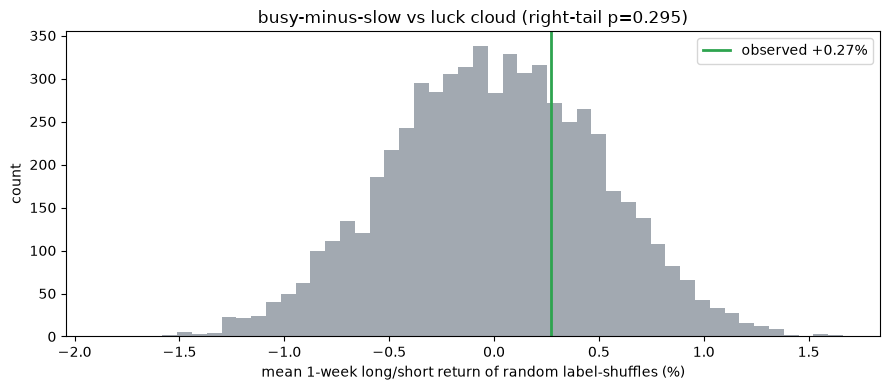

placebo: {'obs': 0.0027, 'placebo_mean': -0.0, 'placebo_sd': 0.005, 'p_value': 0.2946, 'n_draws': 10000}


In [3]:
pl = st.placebo_pvalue(ev, 'fwd_s', tail='right')
n = int((inc['direction']!='flat').sum())
fwd = inc[inc['direction']!='flat']['fwd_s'].values.astype(float)
rng = np.random.default_rng(999); draws = []
for _ in range(6000):
    w = rng.choice((-1.0,1.0), size=n); draws.append(float(np.mean(w*fwd)))
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(np.array(draws)*100, bins=50, color='#8b949e', alpha=0.8)
ax.axvline(pl['obs']*100, color='#2ea44f', lw=2, label=f"observed {pl['obs']*100:+.2f}%")
ax.set_xlabel('mean 1-week long/short return of random label-shuffles (%)'); ax.set_ylabel('count')
ax.set_title(f"busy-minus-slow vs luck cloud (right-tail p={pl['p_value']:.3f})"); ax.legend()
plt.tight_layout(); plt.show()
print('placebo:', {k: round(v,4) if isinstance(v,float) else v for k,v in pl.items()})

## 3. Jackknife — is any single quarter holding it up?

In [4]:
x = st.longshort_returns(ev, 'fwd_l')
jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
print(f'full-sample t = {st.one_sample_t(x)["t"]:+.3f}')
print(f'jackknife t range [{min(jk):+.3f}, {max(jk):+.3f}] over {len(x)} leave-one-out draws')

full-sample t = -0.391
jackknife t range [-0.695, +0.204] over 64 leave-one-out draws


## 4. Tradability — net of costs

Calendar-known entry at the print, so the signal window and the tradable window are the same. There is no gross edge to erode, so costs are almost irrelevant.

In [5]:
ev10 = st.build_event_table(prices, cost_bps=10.0)
for base, label in [('fwd_s','1wk L/S'),('fwd_l','1mo L/S')]:
    g = st.one_sample_t(st.longshort_returns(ev, base))
    n5 = st.one_sample_t(st.longshort_returns(ev, base+'_net'))
    n10 = st.one_sample_t(st.longshort_returns(ev10, base+'_net'))
    print(f'{label:<8s} gross {g["mean"]*100:+.3f}% (t={g["t"]:+.2f})  net@5 {n5["mean"]*100:+.3f}% (t={n5["t"]:+.2f})  net@10 {n10["mean"]*100:+.3f}% (t={n10["t"]:+.2f})')

1wk L/S  gross +0.271% (t=+0.54)  net@5 +0.243% (t=+0.48)  net@10 +0.215% (t=+0.43)


1mo L/S  gross -0.316% (t=-0.39)  net@5 -0.344% (t=-0.43)  net@10 -0.373% (t=-0.46)


## 5. Synthetic positive control — the detector works, the real tape is just empty

The long/short detector must stay quiet on a planted-null world and recover a planted two-sided 'busy→forward-up / slow→forward-down' link. That it fires cleanly on the synthetic world but not on WMT is what makes the real-tape null *trustworthy*, not a broken pipe.

null: mean t=+0.23 sd=1.17  |t|>=2 in 1/20 seeds
planted +2%: mean L/S +2.634%  t=+3.43
planted +4%: mean L/S +4.539%  t=+5.92


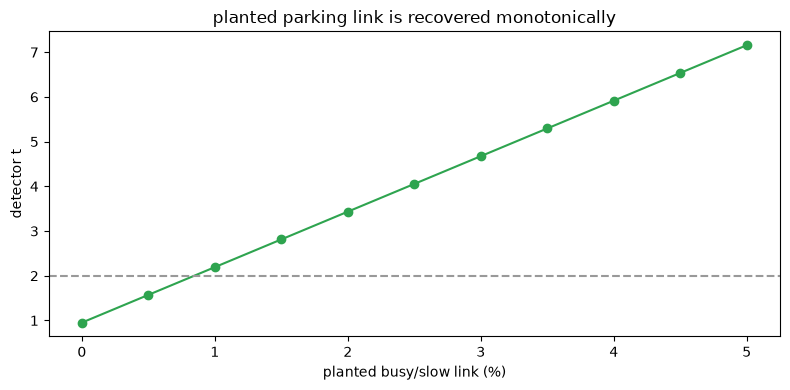

In [6]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=810+s, k=21)['t'] for s in range(20)])
print(f'null: mean t={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  |t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
for b in (0.02, 0.04):
    r = st.synthetic_detect(bump=b, seed=810, k=21)
    print(f'planted +{b*100:.0f}%: mean L/S {r["mean"]*100:+.3f}%  t={r["t"]:+.2f}')
bumps = np.linspace(0, 0.05, 11)
ts = [st.synthetic_detect(bump=b, seed=810, k=21)['t'] for b in bumps]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(bumps*100, ts, 'o-', color='#2ea44f')
ax.axhline(2, color='0.6', ls='--'); ax.set_xlabel('planted busy/slow link (%)'); ax.set_ylabel('detector t')
ax.set_title('planted parking link is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: None.** Every cut is a coin-flip: busy/slow forward AR |*t*| < 0.7, long/short spread |*t*| < 0.55 that **flips sign** across horizons, Spearman(yoy, fwd) ≈ 0, sign-shuffle placebo p = 0.29 / 0.65, jackknife *t* straddling zero. The synthetic control fires (*t* = +3.4 at a +2% planted link), so this is a true null, not a broken test. **Tradability: Mirage.** No gross edge to erode, sign-unstable, and the signal is a LABELLED PROXY — not the real, paywalled satellite panel — so even a hypothetical edge here would not be a live, investable feed.